# Imports

In [ ]:
!pip install mne boto3

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
#import mne
from scipy.stats import kurtosis, skew
from scipy.signal import find_peaks, peak_widths, welch, stft # Import welch here
import pywt
import math
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)


In [ ]:
base_path='/content/drive/MyDrive/P300_expanded'
subject_list=['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55']
output_dir='/content/drive/MyDrive/P300_expanded/feature_extracted'

In [ ]:
url2 = "https://docs.google.com/spreadsheets/d/1WRv_tr8ReLbLvRK9okeBQPJOJ_jlgC1g_5ZlYx7gr5g/export?format=csv&gid=552759730"
answer_df = pd.read_csv(url2)

In [ ]:
warnings.filterwarnings('ignore') # Moved to initial import cell for broader effect


# Questionnaire

In [ ]:
url2 = "https://docs.google.com/spreadsheets/d/1WRv_tr8ReLbLvRK9okeBQPJOJ_jlgC1g_5ZlYx7gr5g/export?format=csv&gid=552759730"
answer_df = pd.read_csv(url2)

NameError: name 'pd' is not defined

In [ ]:
def rename_and_encode_columns(answer_df):
    # Rename columns
    rename_map = {
        'Unnamed: 0': 'subject',
        '1': 'handedness',
        '2': 'disease',
        '3': 'age',
        '4': 'gender',
        '5': 'corrected_vision',
        '6': 'biofeedback_exp',
        '16': 'anxiety',
        '17': 'boredom',
        '18': 'physical_state',
        '19': 'mental_state',
        '20': 'eye_state',
        '21': 'performance_prediction',
        '22': 'continue_YN',
        '23': 'anxiety_2',
        '24': 'boredom_2',
        '25': 'physical_state_2',
        '26': 'mental_state_2',
        '27': 'concentration',
        '28': 'eye_state_2',
        '29': 'sleepy',
        '30': 'too_fast',
        '31': 'too_difficult',
        '32': 'concentration_diff',
        '33': 'last_run_perf_pred',
        '34': 'next_run_perf_pred',
        '35': 'continue_YN_2',
        '36': 'anxiety_3',
        '37': 'boredom_3',
        '38': 'concentration_2',
        '39': 'physical_state_3',
        '40': 'mental_state_3',
        '41': 'eye_state_3',
        '42': 'sleepy_2',
        '43': 'too_fast_2',
        '44': 'too_difficult_2',
        '45': 'concentration_diff_2',
        '47': 'next_run_perf_pred_2',
        '48': 'continue_YN_3',
        '49': 'anxiety_4',
        '50': 'boredom_4',
        '51': 'concentration_3',
        '52': 'physical_state_4',
        '53': 'mental_state_4',
        '54': 'eye_state_4',
        '55': 'sleepy_3',
        '56': 'too_fast_3',
        '57': 'too_difficult_3',
        '58': 'concentration_diff_3',
        '60': 'next_run_perf_pred_3',
        '61': 'continue_YN_4',
        '62': 'anxiety_5',
        '63': 'boredom_5',
        '64': 'concentration_4',
        '65': 'physical_state_5',
        '66': 'mental_state_5',
        '67': 'eye_state_5',
        '68': 'sleepy_4',
        '69': 'too_fast_4',
        '70': 'too_difficult_4',
        '71': 'concentration_diff_4',
        '73': 'next_run_perf_pred_4',
        '74': 'anxiety_6',
        '75': 'boredom_6',
        '76': 'concentration_5',
        '77': 'physical_state_6',
        '78': 'mental_state_6',
        '79': 'eye_state_6',
        '80': 'sleepy_5',
        '81': 'too_fast_5',
        '82': 'too_difficult_5',
        '84': 'concentration_diff_5',
        '85': 'duration',
        '86': 'evaluation',
        '87': 'experimental_environment',
        '88': 'task_difficulty'
    }
    answer_df.rename(columns=rename_map, inplace=True)
    # Format subject ID
    answer_df['subject'] = answer_df['subject'].str.extract(r"(\d+)$")[0].astype(int).apply(lambda x: f"{x:02}")

    # Encode categorical columns
    binary_map_yn = {'Y': 1, 'N': 0}
    binary_map_gender = {'F': 1, 'M': 0}
    binary_map_lr = {'L': 0, 'R': 1}

    answer_df['handedness'] = answer_df['handedness'].map(binary_map_lr)
    answer_df['disease'] = answer_df['disease'].map(binary_map_yn)
    answer_df['gender'] = answer_df['gender'].map(binary_map_gender)
    answer_df['corrected_vision'] = answer_df['corrected_vision'].map(binary_map_yn)
    answer_df['biofeedback_exp'] = answer_df['biofeedback_exp'].map(binary_map_yn)
    answer_df['continue_YN'] = answer_df['continue_YN'].map(binary_map_yn)
    answer_df['continue_YN_2'] = answer_df['continue_YN_2'].map(binary_map_yn)
    answer_df['continue_YN_3'] = answer_df['continue_YN_3'].map(binary_map_yn)
    answer_df['continue_YN_4'] = answer_df['continue_YN_4'].map(binary_map_yn)
    return answer_df

# Usage example:
answer_df = rename_and_encode_columns(answer_df)

In [ ]:
missing_values = answer_df.isnull().sum()
# Display only columns with missing values
missing_values[missing_values > 0]
# answer_df.fillna(1, inplace=True)
print(answer_df.head())

# Dimensionality Reduction: Feature Extraction

In [ ]:
def bandpower(freqs, psd, band):
    idx = np.logical_and(freqs >= band[0], freqs <= band[1])
    return np.trapz(psd[idx], freqs[idx])

def spectral_entropy(psd):
    psd_norm = psd / np.sum(psd)
    psd_norm = np.where(psd_norm == 0, 1e-12, psd_norm)
    se = -np.sum(psd_norm * np.log2(psd_norm))
    return se / np.log2(len(psd_norm))

def spectral_edge_frequency(freqs, psd, edge=0.9):
    psd_norm = psd / np.sum(psd)
    cumsum = np.cumsum(psd_norm)
    idx = np.where(cumsum >= edge)[0][0]
    return freqs[idx]

def spectral_slope(freqs, psd, freq_range=(1,30)):
    valid_idx = np.logical_and(freqs >= freq_range[0], freqs <= freq_range[1])
    log_freqs = np.log10(freqs[valid_idx])
    log_psd = np.log10(psd[valid_idx])
    slope, _ = np.polyfit(log_freqs, log_psd, 1)
    return slope

def band_peak_freq(freqs, psd, band):
    idx = np.logical_and(freqs >= band[0], freqs <= band[1])
    if np.any(idx):
        peak_idx = np.argmax(psd[idx])
        return freqs[idx][peak_idx]
    else:
        return np.nan

def wavelet_energies(signal, wavelet='db4', level=4):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    energies = []
    for c in coeffs[1:]:  # Ignore approximation coeffs
        energies.append(np.sum(np.square(c)))
    return energies

def row_ft_extract(signal):
    signal = np.array(signal)
    pre_stim = signal[0:26]
    post_stim = signal[26:]

    t_end = 0.8
    n_samples = len(signal)

    #---- Time Domain Features----
    p3 = np.max(signal)
    t_start = -0.2
    time_step = (t_end - t_start) / n_samples
    time_axis = np.linspace(t_start, t_end, n_samples)
    latency_p3 = t_start + np.argmax(signal) * time_step

    n2 = np.min(signal)
    latency_n2 = t_start + np.argmin(signal) * time_step

    half_max = p3 / 2
    above_half_max = np.where(signal >= half_max)[0]
    if len(above_half_max) > 0:
        fwhm_start = time_axis[above_half_max[0]]
        fwhm_end = time_axis[above_half_max[-1]]
        fwhm = fwhm_end - fwhm_start
    else:
        fwhm = 0

    t_start_1 = latency_p3 - 0.125
    t_end_1 = latency_p3 + 0.125
    index_start = int((t_start_1 + 0.2) / time_step)
    index_end = int((t_end_1 + 0.2) / time_step)

    avg_amp = np.mean(signal[index_start:index_end])

    p2p = p3 - n2
    auc = np.trapz(signal[26:], dx=time_step)

    swindow_start = latency_p3 - 0.1
    swindow_end = latency_p3
    slope_start_idx = int((swindow_start + 0.2) / time_step)
    slope_end_idx = int((swindow_end + 0.2) / time_step)
    time_seg = time_axis[slope_start_idx:slope_end_idx]
    signal_seg = signal[slope_start_idx:slope_end_idx]

    if(len(time_seg)==0):
      slope=np.nan
    else:
      slope = np.polyfit(time_seg, signal_seg, 1)[0]

    std_dev = np.std(signal)

    # Frequency Domain Features
    delta_band = (0.5, 4)
    theta_band = (4, 8)
    alpha_band = (8, 13)
    beta_band = (13, 30)

    freqs, psd = welch(post_stim, fs=128, nperseg=256)

    delta_power = bandpower(freqs, psd, delta_band)
    theta_power = bandpower(freqs, psd, theta_band)
    alpha_power = bandpower(freqs, psd, alpha_band)
    beta_power = bandpower(freqs, psd, beta_band)

    delta_theta = delta_power / theta_power
    theta_alpha = theta_power / alpha_power
    alpha_beta = alpha_power / beta_power
    theta_beta = theta_power / beta_power

    spec_entropy = spectral_entropy(psd)
    spec_edge_freq = spectral_edge_frequency(freqs, psd)
    spec_slope = spectral_slope(freqs, psd)

    delta_peak_freq = band_peak_freq(freqs, psd, delta_band)
    theta_peak_freq = band_peak_freq(freqs, psd, theta_band)
    alpha_peak_freq = band_peak_freq(freqs, psd, alpha_band)
    beta_peak_freq = band_peak_freq(freqs, psd, beta_band)

    #freq_pre, psd_pre = welch(pre_stim, fs=128, nperseg=26)
    signal = pre_stim
    # your signal segment (e.g., 26 samples)
    n_fft = 64  # or larger, with zero-padding
    window = np.hanning(len(signal))
    fft_result = np.fft.fft(signal * window, n=n_fft)
    psd = (np.abs(fft_result) ** 2) / (len(signal) * np.sum(window ** 2))
    freqs = np.fft.fftfreq(n_fft, d=1/128)
    positive_freqs = freqs[:n_fft//2]
    positive_psd = psd[:n_fft//2]

    alpha_power_pre = bandpower(positive_freqs, positive_psd, alpha_band)
    theta_power_pre = bandpower(positive_freqs, positive_psd, theta_band)

    alpha_suppress = ((alpha_power - alpha_power_pre) / alpha_power_pre) * 100
    theta_enhance = ((theta_power - theta_power_pre) / theta_power_pre) * 100

    wave_energies = wavelet_energies(signal)

    return {
        'P300_amplitude': p3,
        'P300_latency': latency_p3,
        'N2_amplitude': n2,
        'N2_latency': latency_n2,
        'FWHM': fwhm,
        'Avg_amplitude': avg_amp,
        'Peak_to_peak': p2p,
        'AUC': auc,
        'Slope': slope,
        'Std_Dev': std_dev,
        'Delta_power': delta_power,
        'Theta_power': theta_power,
        'Alpha_power': alpha_power,
        'Beta_power': beta_power,
        'Delta_theta_ratio': delta_theta,
        'Theta_alpha_ratio': theta_alpha,
        'Alpha_beta_ratio': alpha_beta,
        'Theta_beta_ratio': theta_beta,
        'Spectral_entropy': spec_entropy,
        'Spectral_edge_frequency': spec_edge_freq,
        'Spectral_slope': spec_slope,
        'Delta_peak_frequency': delta_peak_freq,
        'Theta_peak_frequency': theta_peak_freq,
        'Alpha_peak_frequency': alpha_peak_freq,
        'Beta_peak_frequency': beta_peak_freq,
        'Alpha_suppression_%': alpha_suppress,
        'Theta_enhancement_%': theta_enhance,
        'Wavelet_energies': wave_energies
    }



def ft_extract(data_path, output_path, file_name, chunksize=10000):
    time_cols = [f't_{i}' for i in range(128)]

    # Estimate total rows based on file type
    if 'train' in file_name.lower():
        total_rows = 1582240 # 55 x 899 x 32
    elif 'test' in file_name.lower():
        total_rows = 2215840 # 55 x 1259 x 32
    else:
        # Fallback: count rows in file (slow for large files)
        with open(f'{data_path}/{file_name}.csv') as f:
            total_rows = sum(1 for line in f) - 1  # subtract header

    total_chunks = math.ceil(total_rows / chunksize)
    print(f"Total chunks to process: {total_chunks}")

    reader = pd.read_csv(f'{data_path}/{file_name}.csv', chunksize=chunksize)

    for i, chunk in enumerate(reader, 1):
        feature_df = chunk[time_cols].apply(lambda row: pd.Series(row_ft_extract(row.values)), axis=1)
        result = pd.concat([chunk.drop(columns=time_cols), feature_df], axis=1)

        if i == 1:
            result.to_csv(f'{output_path}/{file_name}_ft.csv', index=False)
        else:
            result.to_csv(f'{output_path}/{file_name}_ft.csv', mode='a', index=False, header=False)

        remaining = total_chunks - i
        print(f"Processed chunk {i}/{total_chunks}. {remaining} chunks remaining.")






In [ ]:
#ft_extract(base_path,output_dir, 'train_1')
print("Doing for train_2")
ft_extract(base_path, output_dir, 'train_2')
#print("Doing for test_1")
#ft_extract(base_path, output_dir, 'test_1')
#print("Doing for test_2")
#ft_extract(base_path, output_dir, 'test_2')
#print("Doing for test_3")
#ft_extract(base_path, output_dir, 'test_3')
#print("Doing for test_4")
#ft_extract(base_path, output_dir, 'test_4')

# Expected CSV format:
# SubjectId, run_type, run_id, epoch_num, epoch_type, channel_name, t_0 to t_127
# SubjectId belongs to [1,55], RUN_TYPE: train/test, run_id (1,2 or 1,2,3,4)
# epoch_num 0 to 1258 or 0 to 898, epoch_type: [target, non-target], t_0 to t_127 in microvolts

Doing for train_2
Total chunks to process: 159
Processed chunk 1/159. 158 chunks remaining.
Processed chunk 2/159. 157 chunks remaining.
Processed chunk 3/159. 156 chunks remaining.
Processed chunk 4/159. 155 chunks remaining.
Processed chunk 5/159. 154 chunks remaining.
Processed chunk 6/159. 153 chunks remaining.
Processed chunk 7/159. 152 chunks remaining.
Processed chunk 8/159. 151 chunks remaining.
Processed chunk 9/159. 150 chunks remaining.
Processed chunk 10/159. 149 chunks remaining.
Processed chunk 11/159. 148 chunks remaining.
Processed chunk 12/159. 147 chunks remaining.
Processed chunk 13/159. 146 chunks remaining.
Processed chunk 14/159. 145 chunks remaining.
Processed chunk 15/159. 144 chunks remaining.
Processed chunk 16/159. 143 chunks remaining.
Processed chunk 17/159. 142 chunks remaining.
Processed chunk 18/159. 141 chunks remaining.
Processed chunk 19/159. 140 chunks remaining.
Processed chunk 20/159. 139 chunks remaining.
Processed chunk 21/159. 138 chunks remaini

In [ ]:
df=pd.read_csv(f'{base_path}/train_1.csv')

In [ ]:
df.head()

,subject_id,run_type,run_id,epoch_num,epoch_type,channel_name,t_0,t_1,t_2,t_3,...,t_118,t_119,t_120,t_121,t_122,t_123,t_124,t_125,t_126,t_127
0,1,train,1,0,non-target,FP1,-2.643773e-06,3.817749e-07,2.967786e-06,2.497375e-06,...,0.000010,0.000015,0.000018,0.000018,0.000017,0.000017,0.000017,0.000018,0.000019,0.000020
1,1,train,1,0,non-target,AF3,2.008377e-06,3.392584e-06,2.432681e-06,7.743079e-08,...,0.000004,0.000007,0.000009,0.000008,0.000007,0.000007,0.000007,0.000006,0.000005,0.000005
2,1,train,1,0,non-target,F7,5.661417e-07,-7.983930e-07,4.907747e-07,1.822997e-06,...,0.000012,0.000014,0.000013,0.000011,0.000010,0.000009,0.000008,0.000007,0.000008,0.000010
3,1,train,1,0,non-target,F3,5.203570e-07,1.980407e-06,3.120540e-06,2.795015e-06,...,0.000003,0.000005,0.000006,0.000005,0.000003,0.000002,0.000002,0.000001,-0.000001,-0.000003
4,1,train,1,0,non-target,FC1,6.532708e-07,1.664096e-06,2.338223e-06,2.110420e-06,...,0.000001,0.000003,0.000005,0.000004,0.000003,0.000003,0.000003,0.000002,-0.000001,-0.000004


In [ ]:
time_cols = [f't_{i}' for i in range(128)]
test_rows = df.head(5)

for idx, row in test_rows.iterrows():
    signal = row[time_cols].astype(float).values  # force float conversion
    features = row_ft_extract(signal)

    # Check for NaNs
    nan_features = [key for key, value in features.items() if isinstance(value, float) and np.isnan(value)]

    print(f"Features for row {idx}:\n", features)
    if nan_features:
        print(f"NaN detected in features: {nan_features}\n")
    else:
        print("No NaNs detected in features.\n")


alpha_power_pre  2.4067165335185225e-12
theta_power_pre  3.6670604895211845e-12
Features for row 0:
 {'P300_amplitude': np.float64(1.98917236328125e-05), 'P300_latency': np.float64(0.7921875), 'N2_amplitude': np.float64(-5.983282089233398e-06), 'N2_latency': np.float64(0.003124999999999989), 'FWHM': np.float64(0.7244094488188977), 'Avg_amplitude': np.float64(1.3536301977494184e-05), 'Peak_to_peak': np.float64(2.5875005722045896e-05), 'AUC': np.float64(5.601343911199364e-06), 'Slope': np.float64(0.0001232420538414965), 'Std_Dev': np.float64(6.23461065985325e-06), 'Delta_power': np.float64(1.9656951763569904e-11), 'Theta_power': np.float64(4.26370208379252e-12), 'Alpha_power': np.float64(7.634990591748836e-13), 'Beta_power': np.float64(2.3962048692366044e-12), 'Delta_theta_ratio': np.float64(4.61030141817161), 'Theta_alpha_ratio': np.float64(5.584423494117098), 'Alpha_beta_ratio': np.float64(0.3186284565969199), 'Theta_beta_ratio': np.float64(1.7793562389141095), 'Spectral_entropy': np.f

/tmp/ipython-input-8211598.py:73: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(signal[26:], dx=time_step)
/tmp/ipython-input-8211598.py:91: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 102, using nperseg = 102
  freqs, psd = welch(post_stim, fs=128, nperseg=256)
/tmp/ipython-input-8211598.py:3: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[idx], freqs[idx])
/usr/local/lib/python3.12/dist-packages/pywt/_multilevel.py:43: UserWarning: Level value of 4 is too high: all coefficients will experience boundary effects.
  warnings.warn(
/tmp/ipython-input-8211598.py:73: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(signal[26:], dx=time_step)

In [ ]:
print(df[time_cols].dtypes)


t_0      float64
t_1      float64
t_2      float64
t_3      float64
t_4      float64
          ...   
t_123    float64
t_124    float64
t_125    float64
t_126    float64
t_127    float64
Length: 128, dtype: object


# Doing Feature Extraction for binned epochs

In [ ]:
# ---------------- PATHS ----------------
base_path = "/content/drive/MyDrive/P300_expanded"
input_folder  = os.path.join(base_path, "binned_epochs")                # where averaged t_0...t_127 exist
output_folder = os.path.join(base_path, "binned_epochs", "feature_extracted_post")

os.makedirs(output_folder, exist_ok=True)


# ---------------- MAIN FUNCTION ----------------
def ft_extract_binned(file_name):
    """
    Extract features from each binned epoch (already averaged)
    and save to feature_extracted_post folder.
    """

    df = pd.read_csv(os.path.join(input_folder, file_name))

    # Identify timepoint columns (t_0 .. t_127)
    time_cols = [c for c in df.columns if c.startswith("t_")]

    # Extract features row-wise
    print(f"Extracting features from {file_name} ...")
    feature_df = df[time_cols].apply(
        lambda row: pd.Series(row_ft_extract(row.values)),
        axis=1
    )

    # Drop wavelet energies because you chose to exclude it
    if "Wavelet_energies" in feature_df.columns:
        feature_df = feature_df.drop(columns=["Wavelet_energies"])

    # Combine metadata with extracted features
    result = pd.concat([df.drop(columns=time_cols), feature_df], axis=1)

    out_path = os.path.join(output_folder, file_name.replace(".csv", "_ft_post.csv"))
    result.to_csv(out_path, index=False)

    print(f"Saved post-bin feature file to:\n{out_path}")

# ------------ RUN ON ONE FILE (example) ----------
ft_extract_binned("train_1_k15_avg.csv")


Extracting features from train_1_k15_avg.csv ...


/tmp/ipython-input-319374820.py:74: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(signal[26:], dx=time_step)
/tmp/ipython-input-319374820.py:96: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 102, using nperseg = 102
  freqs, psd = welch(post_stim, fs=128, nperseg=256)
/tmp/ipython-input-319374820.py:3: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[idx], freqs[idx])
/usr/local/lib/python3.12/dist-packages/pywt/_multilevel.py:43: UserWarning: Level value of 4 is too high: all coefficients will experience boundary effects.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/

Saved post-bin feature file to:
/content/drive/MyDrive/P300_expanded/binned_epochs/feature_extracted_post/train_1_k15_avg_ft_post.csv


# Improved Feature Extraction for binned_epochs

In [ ]:
import numpy as np
import pandas as pd
import math
from scipy.signal import welch
import pywt

# -----------------------
# Helper spectral utilities
# -----------------------
def bandpower(freqs, psd, band):
    """Integrate PSD within band (Hz)."""
    idx = np.logical_and(freqs >= band[0], freqs <= band[1])
    if not np.any(idx):
        return 0.0
    return np.trapz(psd[idx], freqs[idx])

def spectral_entropy(psd):
    """Normalized spectral entropy (base 2)."""
    psd = np.array(psd, dtype=float)
    psd_sum = psd.sum()
    if psd_sum == 0:
        return 0.0
    p = psd / psd_sum
    p = np.where(p <= 0, 1e-12, p)
    se = -np.sum(p * np.log2(p))
    return se / np.log2(len(p))

def spectral_edge_frequency(freqs, psd, edge=0.9):
    """Return frequency where cumulative PSD reaches edge (e.g., 0.9)."""
    freqs = np.array(freqs)
    psd = np.array(psd, dtype=float)
    s = psd.sum()
    if s == 0:
        return np.nan
    cumsum = np.cumsum(psd / s)
    idxs = np.where(cumsum >= edge)[0]
    return freqs[idxs[0]] if idxs.size else freqs[-1]

def spectral_slope(freqs, psd, freq_range=(1, 30)):
    """Estimate 1/f slope using log-log linear fit in given freq_range."""
    freqs = np.array(freqs)
    psd = np.array(psd, dtype=float)

    mask = (freqs >= freq_range[0]) & (freqs <= freq_range[1]) & (psd > 0)
    if mask.sum() < 2:
        return np.nan
    lf = np.log10(freqs[mask])
    lp = np.log10(psd[mask])
    slope, intercept = np.polyfit(lf, lp, 1)
    return slope

def band_peak_freq(freqs, psd, band):
    idx = np.logical_and(freqs >= band[0], freqs <= band[1])
    if np.any(idx):
        peak_idx = np.argmax(psd[idx])
        return freqs[idx][peak_idx]
    else:
        return np.nan

# -----------------------
# Wavelet energies
# -----------------------
def wavelet_energies(signal, wavelet='db4', level=4):
    """Return list of energies for detail coefficients (ignoring approximation)."""
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    energies = [np.sum(c**2) for c in coeffs[1:]]  # D1..Dn
    return energies

# -----------------------
# Hjorth parameters
# -----------------------
def hjorth_parameters(x):
    x = np.asarray(x)
    if x.size < 2:
        return (np.nan, np.nan, np.nan)
    dx = np.diff(x)
    ddx = np.diff(dx)
    var_x = x.var()
    var_dx = dx.var()
    var_ddx = ddx.var()
    activity = var_x
    mobility = math.sqrt(var_dx / var_x) if var_x > 0 else np.nan
    complexity = math.sqrt((var_ddx / var_dx) / (var_dx / var_x)) if var_dx > 0 and var_x > 0 else np.nan
    return activity, mobility, complexity

# -----------------------
# Single-row feature extraction
# -----------------------
def row_ft_extract(signal, fs=128.0):
    """
    signal: 1D array-like containing epoch samples from -200ms to +800ms (length typically 128).
    fs: sampling frequency (Hz).
    Returns dict of features.
    """
    signal = np.asarray(signal, dtype=float)
    n_samples = len(signal)
    # time axis [-0.2, 0.8) with endpoint=False for correct sample spacing
    t_start = -0.2
    t_end = 0.8
    time_axis = np.linspace(t_start, t_end, n_samples, endpoint=False)
    # baseline correction using pre-stimulus samples (<= 0 ms)
    pre_mask = time_axis < 0.0  # strict pre-stim
    if pre_mask.sum() == 0:
        baseline = 0.0
    else:
        baseline = np.mean(signal[pre_mask])
    sig = signal - baseline

    # define windows (sec)
    windows = {
        'N1': (0.08, 0.12),
        'N2': (0.15, 0.25),
        'P3': (0.25, 0.5),
        'P3_alt': (0.3, 0.4)  # additional short mean window
    }

    def window_idx(start, end):
        return np.where((time_axis >= start) & (time_axis < end))[0]

    feat = {}

    # Basic stats
    feat['Epoch_len'] = n_samples
    feat['Baseline_mean'] = baseline
    feat['Signal_std'] = np.std(sig)
    feat['Signal_mean'] = np.mean(sig)

    # Time-domain peaks/means
    # N1 peak (min in window)
    n1_idx = window_idx(*windows['N1'])
    if n1_idx.size:
        feat['N1_amplitude'] = np.min(sig[n1_idx])
        feat['N1_latency'] = time_axis[n1_idx][np.argmin(sig[n1_idx])]
    else:
        feat['N1_amplitude'] = np.nan
        feat['N1_latency'] = np.nan

    # N2 peak (min)
    n2_idx = window_idx(*windows['N2'])
    if n2_idx.size:
        feat['N2_amplitude'] = np.min(sig[n2_idx])
        feat['N2_latency'] = time_axis[n2_idx][np.argmin(sig[n2_idx])]
    else:
        feat['N2_amplitude'] = np.nan
        feat['N2_latency'] = np.nan

    # P3 peak (max)
    p3_idx = window_idx(*windows['P3'])
    if p3_idx.size:
        feat['P3_amplitude'] = np.max(sig[p3_idx])
        feat['P3_latency'] = time_axis[p3_idx][np.argmax(sig[p3_idx])]
    else:
        feat['P3_amplitude'] = np.nan
        feat['P3_latency'] = np.nan

    # Peak-to-peak N2->P3
    if not np.isnan(feat['N2_amplitude']) and not np.isnan(feat['P3_amplitude']):
        feat['N2_P3_p2p'] = feat['P3_amplitude'] - feat['N2_amplitude']
    else:
        feat['N2_P3_p2p'] = np.nan

    # Mean amplitudes in common windows
    p3_alt_idx = window_idx(*windows['P3_alt'])
    feat['P3_mean_300_400'] = np.mean(sig[p3_alt_idx]) if p3_alt_idx.size else np.nan
    p3_mean_idx = p3_idx
    feat['P3_mean_250_500'] = np.mean(sig[p3_mean_idx]) if p3_mean_idx.size else np.nan

    # FWHM of P3 (time between first and last crossing of half-max within P3 window)
    if p3_idx.size and not np.isnan(feat['P3_amplitude']):
        half = feat['P3_amplitude'] / 2.0
        mask_half = (time_axis >= windows['P3'][0]) & (time_axis < windows['P3'][1]) & (sig >= half)
        idxs = np.where(mask_half)[0]
        if idxs.size:
            fwhm = time_axis[idxs[-1]] - time_axis[idxs[0]]
        else:
            fwhm = 0.0
    else:
        fwhm = np.nan
    feat['P3_FWHM'] = fwhm

    # Slope: rising slope measured between (latency - 100ms) and (latency)
    if not np.isnan(feat['P3_latency']):
        sw_start = feat['P3_latency'] - 0.1
        sw_end = feat['P3_latency']
        sidx = np.where((time_axis >= sw_start) & (time_axis < sw_end))[0]
        if sidx.size >= 2:
            x = time_axis[sidx]; y = sig[sidx]
            slope = np.polyfit(x, y, 1)[0]
        else:
            slope = np.nan
    else:
        slope = np.nan
    feat['P3_rising_slope'] = slope

    # AUC over P3 window
    if p3_idx.size:
        feat['P3_AUC'] = np.trapz(sig[p3_idx], time_axis[p3_idx])
    else:
        feat['P3_AUC'] = np.nan

    # Half-area latency (time by which half of area from 0..window reached)
    if p3_idx.size:
        area = np.trapz(sig[p3_idx], time_axis[p3_idx])
        if np.isfinite(area) and area != 0:
            cumsum = np.cumsum(np.abs(sig[p3_idx])) * (1.0 / fs)
            half_area_idx = np.where(cumsum >= (cumsum[-1] / 2.0))[0]
            feat['P3_half_area_latency'] = time_axis[p3_idx][half_area_idx[0]] if half_area_idx.size else np.nan
        else:
            feat['P3_half_area_latency'] = np.nan
    else:
        feat['P3_half_area_latency'] = np.nan

    # RMS in post-stim window (0..800 ms)
    post_mask = time_axis >= 0.0
    sig_post = sig[post_mask]
    feat['Post_RMS'] = np.sqrt(np.mean(sig_post**2)) if sig_post.size else np.nan

    # Hjorth
    activity, mobility, complexity = hjorth_parameters(sig_post if sig_post.size else sig)
    feat['Hjorth_activity'] = activity
    feat['Hjorth_mobility'] = mobility
    feat['Hjorth_complexity'] = complexity

    # -----------------------
    # Frequency-domain (use full post-stim)
    # -----------------------
    # ensure at least 2 samples for welch
    if sig_post.size < 2:
        freqs = np.array([0.0])
        psd = np.array([0.0])
    else:
        nperseg = sig_post.size
        freqs, psd = welch(sig_post, fs=fs, nperseg=nperseg)

    # Bands
    delta_band = (0.5, 4)
    theta_band = (4, 8)
    alpha_band = (8, 13)
    beta_band = (13, 30)

    # band powers
    feat['Delta_power'] = bandpower(freqs, psd, delta_band)
    feat['Theta_power'] = bandpower(freqs, psd, theta_band)
    feat['Alpha_power'] = bandpower(freqs, psd, alpha_band)
    feat['Beta_power'] = bandpower(freqs, psd, beta_band)

    # safe ratios
    eps = 1e-12
    feat['Delta_theta_ratio'] = feat['Delta_power'] / (feat['Theta_power'] + eps)
    feat['Theta_alpha_ratio'] = feat['Theta_power'] / (feat['Alpha_power'] + eps)
    feat['Alpha_beta_ratio'] = feat['Alpha_power'] / (feat['Beta_power'] + eps)
    feat['Theta_beta_ratio'] = feat['Theta_power'] / (feat['Beta_power'] + eps)

    feat['Spectral_entropy'] = spectral_entropy(psd)
    feat['Spectral_edge_frequency_90'] = spectral_edge_frequency(freqs, psd, edge=0.9)
    feat['Spectral_slope_1_30'] = spectral_slope(freqs, psd, freq_range=(1,30))

    feat['Delta_peak_freq'] = band_peak_freq(freqs, psd, delta_band)
    feat['Theta_peak_freq'] = band_peak_freq(freqs, psd, theta_band)
    feat['Alpha_peak_freq'] = band_peak_freq(freqs, psd, alpha_band)
    feat['Beta_peak_freq'] = band_peak_freq(freqs, psd, beta_band)

    # -----------------------
    # Pre-stim spectral features (using exactly pre-stim samples)
    # -----------------------
    pre_mask = time_axis < 0.0
    pre_sig = sig[pre_mask]
    if pre_sig.size >= 2:
        nfft = 1 << (int(np.ceil(np.log2(pre_sig.size))) + 1)  # zero-pad to next power of two*2 for freq resolution
        window = np.hanning(pre_sig.size)
        fft_res = np.fft.fft(pre_sig * window, n=nfft)
        psd_pre = (np.abs(fft_res) ** 2) / (pre_sig.size * np.sum(window ** 2))
        freqs_pre = np.fft.fftfreq(nfft, d=1.0/fs)[:nfft//2]
        psd_pre_pos = psd_pre[:nfft//2]
        feat['Alpha_power_pre'] = bandpower(freqs_pre, psd_pre_pos, alpha_band)
        feat['Theta_power_pre'] = bandpower(freqs_pre, psd_pre_pos, theta_band)
    else:
        feat['Alpha_power_pre'] = np.nan
        feat['Theta_power_pre'] = np.nan

    # alpha suppression and theta enhancement (relative % change)
    if np.isfinite(feat.get('Alpha_power_pre', np.nan)) and (feat['Alpha_power_pre'] not in [0, np.nan]):
        feat['Alpha_suppression_pct'] = ((feat['Alpha_power'] - feat['Alpha_power_pre']) / (feat['Alpha_power_pre'])) * 100.0
    else:
        feat['Alpha_suppression_pct'] = np.nan

    if np.isfinite(feat.get('Theta_power_pre', np.nan)) and (feat['Theta_power_pre'] not in [0, np.nan]):
        feat['Theta_enhancement_pct'] = ((feat['Theta_power'] - feat['Theta_power_pre']) / (feat['Theta_power_pre'])) * 100.0
    else:
        feat['Theta_enhancement_pct'] = np.nan

    # -----------------------
    # Wavelet energies on full baseline-corrected epoch
    # -----------------------
    try:
        feat['Wavelet_energies'] = wavelet_energies(sig, wavelet='db4', level=4)
    except Exception:
        feat['Wavelet_energies'] = [np.nan] * 4

    return feat

# -----------------------
# CSV chunked extractor
# -----------------------
def ft_extract(data_path, output_path, file_name, chunksize=10000, fs=128.0):
    """
    Read CSV with time columns t_0..t_127 and other meta columns.
    Writes <file_name>_ft.csv with features appended.
    """
    time_cols = [f't_{i}' for i in range(128)]
    csv_in = f'{data_path}/{file_name}.csv'
    csv_out = f'{output_path}/{file_name}_ft.csv'

    # If you don't know total rows, estimate by quick pass (optional).
    # We'll attempt to infer from file length, but not required.
    reader = pd.read_csv(csv_in, chunksize=chunksize)
    first = True
    chunk_i = 0

    for chunk in reader:
        chunk_i += 1
        # Ensure time columns exist
        if not set(time_cols).issubset(chunk.columns):
            raise ValueError("Input CSV must contain time columns named t_0..t_127")

        # apply row extraction
        def _apply_row(row):
            vals = row[time_cols].values.astype(float)
            return pd.Series(row_ft_extract(vals, fs=fs))

        feature_df = chunk[time_cols].apply(lambda r: pd.Series(row_ft_extract(r.values.astype(float), fs=fs)), axis=1)

        result = pd.concat([chunk.drop(columns=time_cols), feature_df], axis=1)

        if first:
            result.to_csv(csv_out, index=False)
            first = False
        else:
            result.to_csv(csv_out, index=False, mode='a', header=False)

        print(f'Processed chunk {chunk_i} (rows {len(chunk)}) and appended to {csv_out}')

    print('All chunks processed.')

# -----------------------
# Example usage:
# -----------------------
# epoch = np.random.randn(128)  # replace with real epoch
# feats = row_ft_extract(epoch, fs=128.0)
# print(feats)
#
# ft_extract('/data', '/out', 'train', chunksize=2000, fs=128.0)

**Reasoning**:
First, I will create the output directory for the new feature extracted files if it does not already exist.



In [ ]:
import os
base_path = '/content/drive/MyDrive/P300_expanded'
output_dir = os.path.join(base_path, 'feature_extracted_new')
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory '{output_dir}' ensured to exist.")

Output directory '/content/drive/MyDrive/P300_expanded/feature_extracted_new' ensured to exist.


In [ ]:
files_to_process = ['test_3', 'test_4']

for file_name in files_to_process:
    print(f"\nProcessing file: {file_name}.csv")
    ft_extract(base_path, output_dir, file_name)


Processing file: test_3.csv
Processed chunk 1 (rows 10000) and appended to /content/drive/MyDrive/P300_expanded/feature_extracted_new/test_3_ft.csv
Processed chunk 2 (rows 10000) and appended to /content/drive/MyDrive/P300_expanded/feature_extracted_new/test_3_ft.csv
Processed chunk 3 (rows 10000) and appended to /content/drive/MyDrive/P300_expanded/feature_extracted_new/test_3_ft.csv
Processed chunk 4 (rows 10000) and appended to /content/drive/MyDrive/P300_expanded/feature_extracted_new/test_3_ft.csv
Processed chunk 5 (rows 10000) and appended to /content/drive/MyDrive/P300_expanded/feature_extracted_new/test_3_ft.csv
Processed chunk 6 (rows 10000) and appended to /content/drive/MyDrive/P300_expanded/feature_extracted_new/test_3_ft.csv
Processed chunk 7 (rows 10000) and appended to /content/drive/MyDrive/P300_expanded/feature_extracted_new/test_3_ft.csv
Processed chunk 8 (rows 10000) and appended to /content/drive/MyDrive/P300_expanded/feature_extracted_new/test_3_ft.csv
Processed c

# Time Domain Feature Extraction

In [ ]:
import numpy as np
import pandas as pd

# -----------------------
# Single-row feature extraction (Time-Domain Only)
# -----------------------
# change the sampling frequency fs to 512 from 128.0 once all new files have been processed
def row_ft_extract(signal, fs=128.0):
    """
    signal: 1D array-like containing epoch samples from -200ms to +800ms (length typically 128).
    fs: sampling frequency (Hz).
    Returns dict of time-domain features.
    """
    signal = np.asarray(signal, dtype=float)
    n_samples = len(signal)

    # time axis [-0.2, 0.8) with endpoint=False for correct sample spacing
    t_start = -0.2
    t_end = 0.8
    time_axis = np.linspace(t_start, t_end, n_samples, endpoint=False)

    # baseline correction using pre-stimulus samples (<= 0 ms)
    pre_mask = time_axis < 0.0  # strict pre-stim
    if pre_mask.sum() == 0:
        baseline = 0.0
    else:
        baseline = np.mean(signal[pre_mask])
    # sig = signal - baseline
    sig = signal

    # define windows (sec)
    windows = {
        'N1': (0.08, 0.12),
        'N2': (0.15, 0.25),
        'P3': (0.25, 0.5),
        'P3_alt': (0.3, 0.4)  # additional short mean window
    }

    def window_idx(start, end):
        return np.where((time_axis >= start) & (time_axis < end))[0]

    feat = {}

    # Basic stats
    feat['Epoch_len'] = n_samples
    feat['Baseline_mean'] = baseline
    feat['Signal_std'] = np.std(sig)
    feat['Signal_mean'] = np.mean(sig)

    # Time-domain peaks/means
    # N1 peak (min in window)
    n1_idx = window_idx(*windows['N1'])
    if n1_idx.size:
        feat['N1_amplitude'] = np.min(sig[n1_idx])
        feat['N1_latency'] = time_axis[n1_idx][np.argmin(sig[n1_idx])]
    else:
        feat['N1_amplitude'] = np.nan
        feat['N1_latency'] = np.nan

    # N2 peak (min)
    n2_idx = window_idx(*windows['N2'])
    if n2_idx.size:
        feat['N2_amplitude'] = np.min(sig[n2_idx])
        feat['N2_latency'] = time_axis[n2_idx][np.argmin(sig[n2_idx])]
    else:
        feat['N2_amplitude'] = np.nan
        feat['N2_latency'] = np.nan

    # P3 peak (max)
    p3_idx = window_idx(*windows['P3'])
    if p3_idx.size:
        feat['P3_amplitude'] = np.max(sig[p3_idx])
        feat['P3_latency'] = time_axis[p3_idx][np.argmax(sig[p3_idx])]
    else:
        feat['P3_amplitude'] = np.nan
        feat['P3_latency'] = np.nan

    # Peak-to-peak N2->P3
    if not np.isnan(feat['N2_amplitude']) and not np.isnan(feat['P3_amplitude']):
        feat['N2_P3_p2p'] = feat['P3_amplitude'] - feat['N2_amplitude']
    else:
        feat['N2_P3_p2p'] = np.nan

    # Mean amplitudes in common windows
    p3_alt_idx = window_idx(*windows['P3_alt'])
    feat['P3_mean_300_400'] = np.mean(sig[p3_alt_idx]) if p3_alt_idx.size else np.nan
    p3_mean_idx = p3_idx
    feat['P3_mean_250_500'] = np.mean(sig[p3_mean_idx]) if p3_mean_idx.size else np.nan

    # FWHM of P3 (time between first and last crossing of half-max within P3 window)
    if p3_idx.size and not np.isnan(feat['P3_amplitude']):
        half = feat['P3_amplitude'] / 2.0
        mask_half = (time_axis >= windows['P3'][0]) & (time_axis < windows['P3'][1]) & (sig >= half)
        idxs = np.where(mask_half)[0]
        if idxs.size:
            fwhm = time_axis[idxs[-1]] - time_axis[idxs[0]]
        else:
            fwhm = 0.0
    else:
        fwhm = np.nan
    feat['P3_FWHM'] = fwhm

    # Slope: rising slope measured between (latency - 100ms) and (latency)
    if not np.isnan(feat['P3_latency']):
        sw_start = feat['P3_latency'] - 0.1
        sw_end = feat['P3_latency']
        sidx = np.where((time_axis >= sw_start) & (time_axis < sw_end))[0]
        if sidx.size >= 2:
            x = time_axis[sidx]
            y = sig[sidx]
            slope = np.polyfit(x, y, 1)[0]
        else:
            slope = np.nan
    else:
        slope = np.nan
    feat['P3_rising_slope'] = slope

    # AUC over P3 window
    if p3_idx.size:
        feat['P3_AUC'] = np.trapz(sig[p3_idx], time_axis[p3_idx])
    else:
        feat['P3_AUC'] = np.nan

    # Half-area latency (time by which half of area from 0..window reached)
    if p3_idx.size:
        area = np.trapz(sig[p3_idx], time_axis[p3_idx])
        if np.isfinite(area) and area != 0:
            cumsum = np.cumsum(np.abs(sig[p3_idx])) * (1.0 / fs)
            half_area_idx = np.where(cumsum >= (cumsum[-1] / 2.0))[0]
            feat['P3_half_area_latency'] = time_axis[p3_idx][half_area_idx[0]] if half_area_idx.size else np.nan
        else:
            feat['P3_half_area_latency'] = np.nan
    else:
        feat['P3_half_area_latency'] = np.nan

    # RMS in post-stim window (0..800 ms)
    post_mask = time_axis >= 0.0
    sig_post = sig[post_mask]
    feat['Post_RMS'] = np.sqrt(np.mean(sig_post**2)) if sig_post.size else np.nan

    return feat

# -----------------------
# CSV chunked extractor
# -----------------------
def ft_extract(data_path, output_path, file_name, chunksize=10000, fs=128.0):
    """
    Read CSV with time columns t_0..t_127 and other meta columns.
    Writes <file_name>_ft.csv with features appended.
    """
    time_cols = [f't_{i}' for i in range(128)]
    csv_in = f'{data_path}/{file_name}.csv'
    csv_out = f'{output_path}/{file_name}_ft.csv'

    reader = pd.read_csv(csv_in, chunksize=chunksize)
    first = True
    chunk_i = 0

    for chunk in reader:
        chunk_i += 1
        # Ensure time columns exist
        if not set(time_cols).issubset(chunk.columns):
            raise ValueError("Input CSV must contain time columns named t_0..t_127")

        # apply row extraction to chunk
        feature_df = chunk[time_cols].apply(lambda r: pd.Series(row_ft_extract(r.values.astype(float), fs=fs)), axis=1)

        # merge metadata/original data with new features
        result = pd.concat([chunk.drop(columns=time_cols), feature_df], axis=1)

        if first:
            result.to_csv(csv_out, index=False)
            first = False
        else:
            result.to_csv(csv_out, index=False, mode='a', header=False)

        print(f'Processed chunk {chunk_i} (rows {len(chunk)}) and appended to {csv_out}')

    print('All chunks processed.')

In [ ]:
import os
base_path = '/content/drive/MyDrive/P300_expanded'
output_dir = os.path.join(base_path, 'feature_extracted_new')
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory '{output_dir}' ensured to exist.")

Output directory '/content/drive/MyDrive/P300_expanded/feature_extracted_new' ensured to exist.


In [ ]:
files_to_process = ['train_1']

for file_name in files_to_process:
    print(f"\nProcessing file: {file_name}.csv")
    ft_extract(base_path, output_dir, file_name)


Processing file: train_1.csv


/tmp/ipykernel_246/4272875554.py:119: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  feat['P3_AUC'] = np.trapz(sig[p3_idx], time_axis[p3_idx])
/tmp/ipykernel_246/4272875554.py:125: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(sig[p3_idx], time_axis[p3_idx])


Processed chunk 1 (rows 10000) and appended to /content/drive/MyDrive/P300_expanded/feature_extracted_new/train_1_ft.csv


/tmp/ipykernel_246/4272875554.py:119: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  feat['P3_AUC'] = np.trapz(sig[p3_idx], time_axis[p3_idx])
/tmp/ipykernel_246/4272875554.py:125: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(sig[p3_idx], time_axis[p3_idx])


Processed chunk 2 (rows 10000) and appended to /content/drive/MyDrive/P300_expanded/feature_extracted_new/train_1_ft.csv


...

Processed chunk 157 (rows 10000) and appended to /content/drive/MyDrive/P300_expanded/feature_extracted_new/train_1_ft.csv


/tmp/ipykernel_246/4272875554.py:119: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  feat['P3_AUC'] = np.trapz(sig[p3_idx], time_axis[p3_idx])
/tmp/ipykernel_246/4272875554.py:125: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(sig[p3_idx], time_axis[p3_idx])


Processed chunk 158 (rows 10000) and appended to /content/drive/MyDrive/P300_expanded/feature_extracted_new/train_1_ft.csv


/tmp/ipykernel_246/4272875554.py:119: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  feat['P3_AUC'] = np.trapz(sig[p3_idx], time_axis[p3_idx])
/tmp/ipykernel_246/4272875554.py:125: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(sig[p3_idx], time_axis[p3_idx])


Processed chunk 159 (rows 2240) and appended to /content/drive/MyDrive/P300_expanded/feature_extracted_new/train_1_ft.csv
All chunks processed.


Outlier Handling and statistical validation

Total rows loaded: 1582240
Columns: ['subject_id', 'run_type', 'run_id', 'epoch_num', 'epoch_type', 'channel_name', 'Epoch_len', 'Baseline_mean', 'Signal_std', 'Signal_mean', 'N1_amplitude', 'N1_latency', 'N2_amplitude', 'N2_latency', 'P3_amplitude', 'P3_latency', 'N2_P3_p2p', 'P3_mean_300_400', 'P3_mean_250_500', 'P3_FWHM', 'P3_rising_slope', 'P3_AUC', 'P3_half_area_latency', 'Post_RMS']
Rows at Pz: 49445
Before (NaNs removed): 49445
After cleaning: 48884
Removed %: 1.13%


/tmp/ipykernel_246/4241540830.py:54: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(remove_outliers_z)


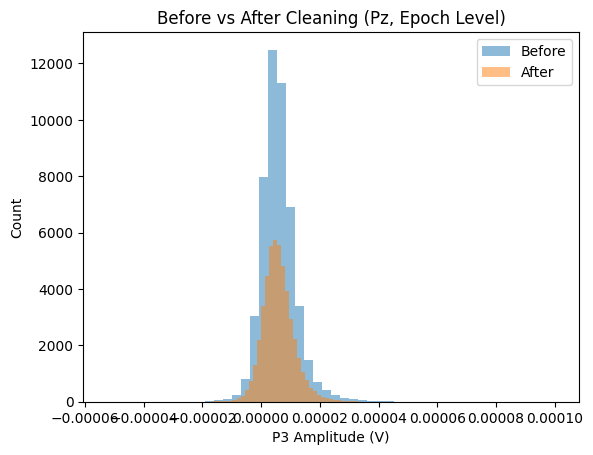

/tmp/ipykernel_246/4241540830.py:87: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_before['P3_amplitude'], df_clean['P3_amplitude']],


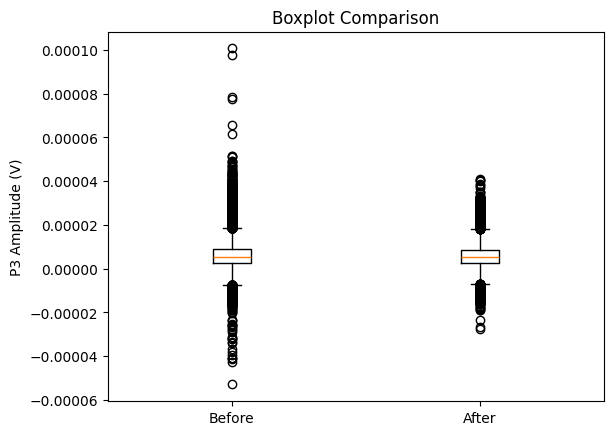

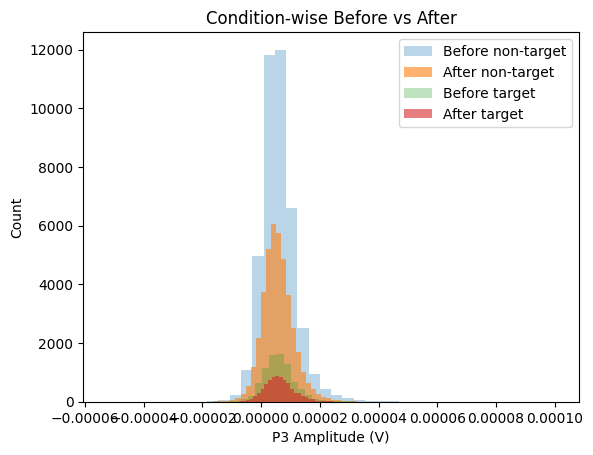

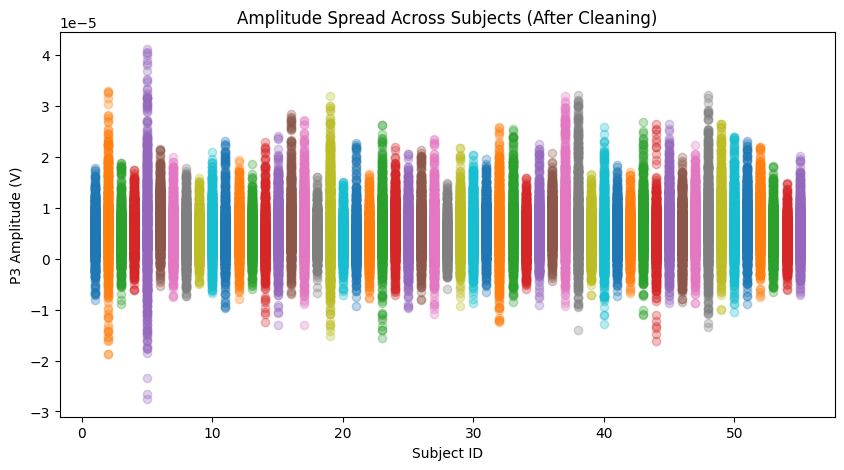

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# =========================
# 1. LOAD DATA
# =========================
file_path = os.path.join(output_dir, 'train_1_ft.csv')  # make sure output_dir is defined
df = pd.read_csv(file_path)

print("Total rows loaded:", len(df))
print("Columns:", df.columns.tolist())


# =========================
# 2. FILTER → Pz CHANNEL
# =========================
df_pz = df[df['channel_name'] == 'Pz'].copy()

# Swapped latency for amplitude
df_pz = df_pz[['subject_id', 'run_id', 'epoch_num', 'epoch_type', 'P3_amplitude']]

print("Rows at Pz:", len(df_pz))


# =========================
# 3. BEFORE DATASET
# (Drop NaNs for amplitude instead of latency bounds)
# =========================
df_before = df_pz.dropna(subset=['P3_amplitude']).copy()

print("Before (NaNs removed):", len(df_before))


# =========================
# 4. OUTLIER REMOVAL (Z-score)
# epoch-level, per subject + condition
# =========================
def remove_outliers_z(group, threshold=3):
    vals = group['P3_amplitude'] # Targeted amplitude

    std = vals.std(ddof=0)
    if std == 0 or np.isnan(std):
        return group

    z = (vals - vals.mean()) / std
    return group[np.abs(z) <= threshold]


df_clean = (
    df_before
    .groupby(['subject_id', 'epoch_type'], group_keys=False)
    .apply(remove_outliers_z)
)

print("After cleaning:", len(df_clean))


# =========================
# 5. REMOVAL STATS
# =========================
removed_pct = 100 * (1 - len(df_clean) / len(df_before)) if len(df_before) > 0 else 0

print(f"Removed %: {removed_pct:.2f}%")


# =========================
# 6. VISUALIZATION
# =========================



# --- Histogram (Before vs After) ---
plt.figure()
plt.hist(df_before['P3_amplitude'], bins=50, alpha=0.5, label='Before')
plt.hist(df_clean['P3_amplitude'], bins=50, alpha=0.5, label='After')
plt.xlabel('P3 Amplitude (V)') # Adjusted label
plt.ylabel('Count')
plt.title('Before vs After Cleaning (Pz, Epoch Level)')
plt.legend()
plt.show()


# --- Boxplot ---
plt.figure()
plt.boxplot([df_before['P3_amplitude'], df_clean['P3_amplitude']],
            labels=['Before', 'After'])
plt.ylabel('P3 Amplitude (V)') # Adjusted label
plt.title('Boxplot Comparison')
plt.show()


# --- Condition-wise Histogram ---
plt.figure()

for cond in sorted(df_before['epoch_type'].unique()):
    before_vals = df_before[df_before['epoch_type'] == cond]['P3_amplitude']
    after_vals  = df_clean[df_clean['epoch_type'] == cond]['P3_amplitude']

    plt.hist(before_vals, bins=40, alpha=0.3, label=f'Before {cond}')
    plt.hist(after_vals, bins=40, alpha=0.6, label=f'After {cond}')

plt.xlabel('P3 Amplitude (V)') # Adjusted label
plt.ylabel('Count')
plt.title('Condition-wise Before vs After')
plt.legend()
plt.show()


# --- Subject spread ---
plt.figure(figsize=(10,5))

for subj in df_clean['subject_id'].unique():
    subset = df_clean[df_clean['subject_id'] == subj]
    plt.scatter([subj]*len(subset), subset['P3_amplitude'], alpha=0.3)

plt.xlabel('Subject ID')
plt.ylabel('P3 Amplitude (V)') # Adjusted label
plt.title('Amplitude Spread Across Subjects (After Cleaning)')
plt.show()

# Time Domain Feature Extraction for Parquet

In [ ]:
import mne
import boto3
import tempfile
import os
import io
from google.colab import userdata

In [ ]:
def row_ft_extract(signal, fs=512.0):
    signal = np.asarray(signal, dtype=float)
    n_samples = len(signal)
    t_start, t_end = -0.2, 0.8
    time_axis = np.linspace(t_start, t_end, n_samples, endpoint=False)
    dt = 1.0 / fs

    # --- Baseline correction (actually apply it) ---

    pre_mask = time_axis < 0.0
    baseline = np.mean(signal[pre_mask]) if pre_mask.sum() > 0 else 0.0
    #sig = signal - baseline  # ← actually subtract
    sig = signal

    windows = {
        'N1':    (0.08, 0.13),
        'P2':    (0.13, 0.18),  # added
        'N2':    (0.18, 0.25),
        'P3':    (0.25, 0.50),
        'P3_alt':(0.30, 0.40),
        'late':  (0.50, 0.80),  # added
    }

    def window_idx(start, end):
        return np.where((time_axis >= start) & (time_axis < end))[0]

    feat = {}
    feat['Baseline_mean'] = baseline
    feat['Signal_std']    = np.std(sig)
    feat['Signal_mean']   = np.mean(sig)
    feat['Signal_kurtosis'] = pd.Series(sig).kurt()
    feat['Signal_skewness'] = pd.Series(sig).skew()

    # Post-stim RMS
    post_mask = time_axis >= 0.0
    feat['Post_RMS'] = np.sqrt(np.mean(sig[post_mask]**2)) if post_mask.sum() else np.nan


    # ERP components
    component_cfg = {
        'N1': ('min', windows['N1']),
        'P2': ('max', windows['P2']),
        'N2': ('min', windows['N2']),
        'P3': ('max', windows['P3']),
        'Late': ('max', windows['late']),
    }
    peak_data = {}
    for name, (direction, win) in component_cfg.items():
        idx = window_idx(*win)
        if idx.size:
            if direction == 'min':
                amp = np.min(sig[idx])
                lat = time_axis[idx[np.argmin(sig[idx])]]
            else:
                amp = np.max(sig[idx])
                lat = time_axis[idx[np.argmax(sig[idx])]]
            feat[f'{name}_amplitude'] = amp
            feat[f'{name}_latency']   = lat
            feat[f'{name}_mean']      = np.mean(sig[idx])
            feat[f'{name}_AUC']       = np.trapz(sig[idx], time_axis[idx])
        else:
            feat[f'{name}_amplitude'] = np.nan
            feat[f'{name}_latency']   = np.nan
            feat[f'{name}_mean']      = np.nan
            feat[f'{name}_AUC']       = np.nan
        peak_data[name] = feat.get(f'{name}_amplitude', np.nan)

    # Peak-to-peak
    feat['N2_P3_p2p'] = (peak_data['P3'] - peak_data['N2']
                         if not any(np.isnan([peak_data['P3'], peak_data['N2']])) else np.nan)


    # Replace ZCR with latency differences
    feat['N1_N2_lat_diff'] = (feat['N2_latency'] - feat['N1_latency']
                          if not any(np.isnan([feat['N2_latency'], feat['N1_latency']])) else np.nan)

    feat['N2_P3_lat_diff'] = (feat['P3_latency'] - feat['N2_latency']
                          if not any(np.isnan([feat['P3_latency'], feat['N2_latency']])) else np.nan)

    feat['N1_P3_lat_diff'] = (feat['P3_latency'] - feat['N1_latency']
                          if not any(np.isnan([feat['P3_latency'], feat['N1_latency']])) else np.nan)

    feat['P3_Late_lat_diff'] = (feat['Late_latency'] - feat['P3_latency']
                            if not any(np.isnan([feat['Late_latency'], feat['P3_latency']])) else np.nan)

    feat['P2_P3_lat_diff'] = (feat['P3_latency'] - feat['P2_latency']
                          if not any(np.isnan([feat['P3_latency'], feat['P2_latency']])) else np.nan)


    # P3 FWHM
    p3_idx = window_idx(*windows['P3'])
    if p3_idx.size and not np.isnan(feat['P3_amplitude']):
        half     = feat['P3_amplitude'] / 2.0
        mask_half = sig[p3_idx] >= half
        idxs     = np.where(mask_half)[0]
        feat['P3_FWHM'] = (time_axis[p3_idx[idxs[-1]]] - time_axis[p3_idx[idxs[0]]]) if idxs.size else 0.0
    else:
        feat['P3_FWHM'] = np.nan

    # P3 rising slope
    if not np.isnan(feat['P3_latency']):
        sidx = window_idx(feat['P3_latency'] - 0.1, feat['P3_latency'])
        if sidx.size >= 2:
            feat['P3_rising_slope'] = np.polyfit(time_axis[sidx], sig[sidx], 1)[0]
        else:
            feat['P3_rising_slope'] = np.nan
    else:
        feat['P3_rising_slope'] = np.nan

    # P3 half-area latency
    if p3_idx.size:
        cumsum = np.cumsum(np.abs(sig[p3_idx])) * dt
        half_area = np.where(cumsum >= cumsum[-1] / 2.0)[0]
        feat['P3_half_area_latency'] = time_axis[p3_idx[half_area[0]]] if half_area.size else np.nan
    else:
        feat['P3_half_area_latency'] = np.nan

    # P3 mean windows
    feat['P3_mean_300_400'] = np.mean(sig[window_idx(*windows['P3_alt'])]) if window_idx(*windows['P3_alt']).size else np.nan
    feat['P3_mean_250_500'] = np.mean(sig[p3_idx]) if p3_idx.size else np.nan

    return feat

In [ ]:
def ft_extract_parquet(s3_prefix, output_prefix, dataset_cfg, s3_client, bucket):
    import io
    time_cols = [f't_{k}' for k in range(dataset_cfg['n_times'])]
    fs        = dataset_cfg['sfreq']

    # list all parquet files under prefix
    paginator = s3_client.get_paginator('list_objects_v2')
    for page in paginator.paginate(Bucket=bucket, Prefix=s3_prefix):
        for obj in page.get('Contents', []):
            in_key  = obj['Key']
            out_key = in_key.replace(s3_prefix, output_prefix).replace('.parquet', '_ft.parquet')

            buf = io.BytesIO()
            s3_client.download_fileobj(bucket, in_key, buf)
            buf.seek(0)
            df = pd.read_parquet(buf)

            feature_df = df[time_cols].apply(
                lambda r: pd.Series(row_ft_extract(r.values, fs=fs)), axis=1
            )
            result = pd.concat([df.drop(columns=time_cols), feature_df], axis=1)

            out_buf = io.BytesIO()
            result.to_parquet(out_buf, index=False, engine='pyarrow', compression='snappy')
            out_buf.seek(0)
            s3_client.put_object(Bucket=bucket, Key=out_key, Body=out_buf.getvalue())
            print(f"Processed {in_key} → {out_key}")

In [ ]:
# --- 1. S3 Configuration ---
s3 = boto3.client(
    's3',
    aws_access_key_id     = userdata.get('AWS_ACCESS_KEY_ID'),
    aws_secret_access_key = userdata.get('AWS_SECRET_ACCESS_KEY'),
    region_name           = 'ap-south-1'
)

S3_BUCKET = 'amzn-eeg-bucket'

# --- 2. Dataset Configs ---
dataset_configs = {
    'korean': {
        'input_prefix':  'korean/parquet_data',
        'output_prefix': 'korean/parquet_ft',
        'n_times':       512,   # confirm from probe
        'sfreq':         512,   # confirm from probe
    }
}


# --- 3. Helper ---
def s3_key_exists(bucket, key):
    try:
        s3.head_object(Bucket=bucket, Key=key)
        return True
    except s3.exceptions.ClientError as e:
        if e.response['Error']['Code'] == '404':
            return False
        raise

# --- 4. Invocation ---
for dataset_name, cfg in dataset_configs.items():
    print(f"\n{'='*50}")
    print(f"Processing dataset: {dataset_name}")
    print(f"{'='*50}")

    time_cols = [f't_{k}' for k in range(cfg['n_times'])]
    fs        = cfg['sfreq']

    paginator = s3.get_paginator('list_objects_v2')
    for page in paginator.paginate(Bucket=S3_BUCKET, Prefix=cfg['input_prefix']):
        for obj in page.get('Contents', []):
            in_key  = obj['Key']
            out_key = in_key.replace(cfg['input_prefix'], cfg['output_prefix'])

            # Safe resume
            if s3_key_exists(S3_BUCKET, out_key):
                print(f"  [skip] {in_key}")
                continue

            try:
                # Download
                buf = io.BytesIO()
                s3.download_fileobj(S3_BUCKET, in_key, buf)
                buf.seek(0)
                df = pd.read_parquet(buf)

                # Extract features row-wise
                feature_df = df[time_cols].apply(
                    lambda r: pd.Series(row_ft_extract(r.values, fs=fs)), axis=1
                )
                result = pd.concat([df.drop(columns=time_cols), feature_df], axis=1)

                # Upload
                out_buf = io.BytesIO()
                result.to_parquet(out_buf, index=False, engine='pyarrow', compression='snappy')
                out_buf.seek(0)
                s3.put_object(Bucket=S3_BUCKET, Key=out_key, Body=out_buf.getvalue())
                print(f"  [done] {in_key} → {out_key}  ({len(result)} rows)")

            except Exception as e:
                print(f"  [error] {in_key}: {e}")
                continue

print("\nAll datasets processed.")


Processing dataset: korean
  [error] korean/parquet_data/: Could not open Parquet input source '<Buffer>': Parquet file size is 0 bytes
  [skip] korean/parquet_data/test_1/subject_01.parquet
  [skip] korean/parquet_data/test_1/subject_02.parquet
  [skip] korean/parquet_data/test_1/subject_03.parquet
  [done] korean/parquet_data/test_1/subject_04.parquet → korean/parquet_ft/test_1/subject_04.parquet  (40288 rows)
  [done] korean/parquet_data/test_1/subject_05.parquet → korean/parquet_ft/test_1/subject_05.parquet  (40288 rows)
  [done] korean/parquet_data/test_1/subject_06.parquet → korean/parquet_ft/test_1/subject_06.parquet  (40288 rows)
  [done] korean/parquet_data/test_1/subject_07.parquet → korean/parquet_ft/test_1/subject_07.parquet  (40288 rows)
  [done] korean/parquet_data/test_1/subject_08.parquet → korean/parquet_ft/test_1/subject_08.parquet  (40288 rows)
  [done] korean/parquet_data/test_1/subject_09.parquet → korean/parquet_ft/test_1/subject_09.parquet  (40288 rows)
  [done]

In [ ]:
import pandas as pd
import numpy as np

sample_signal = np.random.rand(512) * 1e-5

# Extract features for the S3 version (fs=512.0)
features = row_ft_extract(sample_signal, fs=512.0)

# Display the stored features
print("Extracted Features Structure (S3 Version):")
import json
# Use a formatted print for better readability of the keys
for key, value in features.items():
    print(f"{key}: {value}")

Extracted Features Structure (S3 Version):
Baseline_mean: 4.944982021512249e-06
Signal_std: 2.830635322187059e-06
Signal_mean: 5.002778511033265e-06
Signal_kurtosis: -1.2140073209247817
Signal_skewness: 0.0
Post_RMS: 5.784099715447936e-06
N1_amplitude: 4.195358897259172e-07
N1_latency: 0.10859374999999999
N1_mean: 5.053195890418722e-06
N1_AUC: 2.3274042473843057e-07
P2_amplitude: 9.558788753445564e-06
P2_latency: 0.141796875
P2_mean: 5.152516376535421e-06
P2_AUC: 2.5470018865979337e-07
N2_amplitude: 1.5980479267198478e-07
N2_latency: 0.200390625
N2_mean: 4.487287688356273e-06
N2_AUC: 3.107190853267867e-07
P3_amplitude: 9.866770646912872e-06
P3_latency: 0.391796875
P3_mean: 5.148563103989901e-06
P3_AUC: 1.2758365468833964e-06
Late_amplitude: 9.857593668044382e-06
Late_latency: 0.563671875
Late_mean: 4.901671830886401e-06
Late_AUC: 1.4550711007992595e-06
N2_P3_p2p: 9.706965854240887e-06
N1_N2_lat_diff: 0.091796875
N2_P3_lat_diff: 0.19140625
N1_P3_lat_diff: 0.283203125
P3_Late_lat_diff: 0